# 🎓 World University Rankings Analysis

**Dataset:** Times Higher Education (THE) World University Rankings  
**Scope:** 2,191 institutions across 90+ countries  
**Goal:** Identify what separates top-performing universities and countries, and surface actionable insights for policy and institutional strategy.

---

## 📋 Analysis Outline

| # | Section | What we answer |
|---|---------|----------------|
| 1 | Setup & Data Loading | Libraries, theme, and raw data |
| 2 | Data Cleaning & Preprocessing | All cleaning, type-casting, drops, reorders, nulls |
| 3 | Country-Level Distribution | Which countries dominate the rankings by volume? |
| 4 | Overall Score Analysis by Country | Which countries score highest and most consistently? |
| 5 | Score Breakdown by Metric | Radar profiles across teaching, research, citations, etc. |
| 6 | Student Population & Staff Ratio | How size and staffing relate to performance |
| 7 | Correlation Analysis | Does size or staffing actually affect scores? |
| 8 | International Outlook vs Performance | Does openness to the world predict success? |
| 9 | Key Findings & Recommendations | What should policymakers and institutions take away? |

---

## 1. Setup & Data Loading

We import all required libraries, define the global plot theme, and load the raw CSV.

In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings
warnings.filterwarnings("ignore")

# theme
PALETTE = {
    "primary":   "#2E4057",   # deep navy
    "secondary": "#E07A5F",   # terracotta
    "accent":    "#3D9970",   # emerald
    "muted":     "#A8AABC",   # slate grey
    "bg":        "#F7F7F9",   # off-white background
    "text":      "#1A1A2E",   # near-black text
}

SEQ_CMAP = "YlGnBu"     # sequential  (heatmaps, single-metric bars)
DIV_CMAP = "RdYlGn"     # diverging   (correlation matrices)

def apply_theme():
    mpl.rcParams.update({
        "figure.facecolor":  PALETTE["bg"],
        "axes.facecolor":    PALETTE["bg"],
        "axes.edgecolor":    PALETTE["muted"],
        "axes.labelcolor":   PALETTE["text"],
        "axes.titlecolor":   PALETTE["text"],
        "axes.titlesize":    14,
        "axes.titleweight":  "bold",
        "axes.titlepad":     14,
        "axes.labelsize":    11,
        "axes.spines.top":   False,
        "axes.spines.right": False,
        "axes.grid":         True,
        "grid.color":        "#E0E0E8",
        "grid.linewidth":    0.6,
        "xtick.color":       PALETTE["text"],
        "ytick.color":       PALETTE["text"],
        "xtick.labelsize":   9,
        "ytick.labelsize":   9,
        "text.color":        PALETTE["text"],
        "legend.framealpha": 0.0,
        "figure.dpi":        120,
        "savefig.dpi":       120,
        "font.family":       "sans-serif",
    })

apply_theme()

df_raw = pd.read_csv('world_university_rankings_2191.csv')
print(f"Loaded  →  {df_raw.shape[0]:,} rows  ×  {df_raw.shape[1]} columns")

Loaded  →  2,191 rows  ×  30 columns


## 2. Data Cleaning & Preprocessing

All cleaning operations are consolidated here in a single pipeline:

| Step | Action |
|------|--------|
| **Drop administrative columns** | Remove internal IDs, flags, and metadata with no analytical value |
| **Parse numeric columns** | Strip commas from student counts, `%` from intl-student percentages |
| **Handle range scores** | Convert `"56.4–58.6"` to midpoint `57.5` |
| **Handle nulls** | Label missing gender ratios as `"unavailable"` |
| **Reorder columns** | Group into: identity → overall → stats → dimension scores |
| **Rename** | `location` → `country` for readability |

In [2]:
df = df_raw.copy()

# drop columns
df = df.drop(columns=[
    'disabled', 'apply_link', 'unaccredited',
    'rank_order', 'scores_overall_rank', 'iid',
    'record_type', 'member_level', 'nid', 'closed'
], errors='ignore')

# parse column
if 'stats_number_students' in df.columns:
    df["stats_number_students"] = (
        df["stats_number_students"]
        .astype(str)
        .str.replace(",", "", regex=False)
        .apply(lambda x: int(x) if x.isdigit() else 0)
    )

# parse second column
if 'stats_pc_intl_students' in df.columns:
    df["stats_pc_intl_students"] = (
        df["stats_pc_intl_students"]
        .astype(str)
        .str.replace("%", "", regex=False)
        .apply(lambda x: float(x) if len(x) > 1 else 0.0)
    )

# parse third column
def parse_score(x):
    x = str(x)
    if "–" in x:
        parts = x.split("–")
        try:
            return (float(parts[0]) + float(parts[1])) / 2
        except ValueError:
            return float("nan")
    try:
        return float(x)
    except ValueError:
        return float("nan")

if 'scores_overall' in df.columns:
    df["scores_overall"] = df["scores_overall"].apply(parse_score)

# dealt with nulls
if 'stats_female_male_ratio' in df.columns:
    df["stats_female_male_ratio"] = (
        df["stats_female_male_ratio"].astype("object").fillna("unavailable")
    )

# reordered
desired_columns = [
    "rank", "name", "location",
    "scores_overall",
    "stats_number_students",
    "stats_student_staff_ratio",
    "stats_pc_intl_students",
    "stats_female_male_ratio",
    "scores_teaching",        "scores_teaching_rank",
    "scores_research",        "scores_research_rank",
    "scores_citations",       "scores_citations_rank",
    "scores_industry_income", "scores_industry_income_rank",
    "scores_international_outlook", "scores_international_outlook_rank",
    "url", "aliases"
]
existing_columns = [col for col in desired_columns if col in df.columns]
df = df[existing_columns]

# renaming
if 'location' in df.columns:
    df = df.rename(columns={"location": "country"})

print(f"Clean schema:  {df.shape[1]} columns  |  {df.shape[0]:,} rows")

# Define top_5_universities
top_5_universities = df.sort_values(by='scores_overall', ascending=False).head(5)
print("\nTop 5 universities by overall score:")
display(top_5_universities)

Clean schema:  20 columns  |  2,191 rows

Top 5 universities by overall score:


,rank,name,country,scores_overall,stats_number_students,stats_student_staff_ratio,stats_pc_intl_students,stats_female_male_ratio,scores_teaching,scores_teaching_rank,scores_research,scores_research_rank,scores_citations,scores_citations_rank,scores_industry_income,scores_industry_income_rank,scores_international_outlook,scores_international_outlook_rank,url,aliases
0,1,University of Oxford,United Kingdom,98.2,22005,10.4,43.0,52 : 48,97.2,4,100.0,2,97.7,12,99.9,50,96.4,23,/world-university-rankings/university-oxford,University of Oxford
1,2,Massachusetts Institute of Technology,United States,97.7,11703,7.7,33.0,43 : 57,99.2,1,95.3,11,99.6,1,100.0,15,91.9,97,/world-university-rankings/massachusetts-insti...,Massachusetts Institute of Technology
3,4,University of Cambridge,United Kingdom,97.2,21045,11.3,38.0,50 : 50,96.2,6,99.9,3,97.1,19,87.6,231,96.3,24,/world-university-rankings/university-cambridge,University of Cambridge
2,3,Princeton University,United States,97.2,8739,8.2,23.0,47 : 53,98.2,2,97.3,9,99.0,4,98.0,112,85.4,196,/world-university-rankings/princeton-university,Princeton University
5,6,Stanford University,United States,97.1,17422,5.9,25.0,48 : 52,97.5,3,97.4,8,99.5,2,100.0,25,83.9,215,/world-university-rankings/stanford-university,Stanford University


## 3. Country-Level Distribution

How many universities from each country appear in the global rankings? We look at the **top 30 countries** by number of ranked institutions.

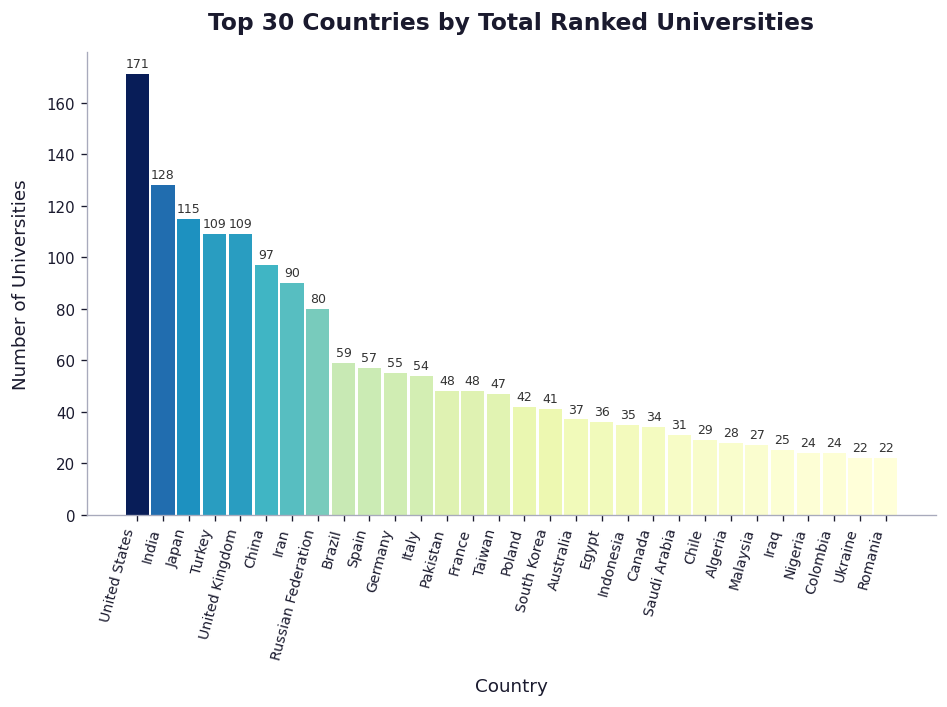

In [18]:
apply_theme()

viz = df["country"].value_counts().reset_index().head(30)
viz.columns = ["country", "count"]

norm = plt.Normalize(viz["count"].min(), viz["count"].max())
colors = [cm.YlGnBu(norm(v)) for v in viz["count"]]

fig, ax = plt.subplots(figsize=(8, 6))

# white background
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

bars = ax.bar(
    viz["country"],
    viz["count"],
    color=colors,
    width=0.9
)

# remove grid
ax.grid(False)

for bar, val in zip(bars, viz["count"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.5,
        str(val),
        ha="center",
        va="bottom",
        fontsize=7.5,
        color="#333"
    )

ax.set_xlabel("Country", labelpad=10)
ax.set_ylabel("Number of Universities", labelpad=10)
ax.set_title("Top 30 Countries by Total Ranked Universities")

ax.set_xticks(range(len(viz)))
ax.set_xticklabels(
    viz["country"],
    rotation=75,
    ha="right",
    fontsize=8.5
)

ax.yaxis.set_major_locator(
    ticker.MaxNLocator(integer=True)
)

plt.tight_layout()
plt.show()

> **Observation:** The **United States, India, and Japan** lead by sheer number of ranked institutions. Having many ranked universities doesn't automatically signal consistent quality — a country can have a handful of world-class institutions alongside many mediocre ones. The next sections investigate this tension directly.

## 4. Overall Score Analysis by Country

### Score Spread — Top 15 Countries

The chart below shows the **range** (min → max) and **mean** overall score for the top 15 countries by their best score. Wide bars reveal systems where a few elite universities carry the average up, while many institutions lag behind.

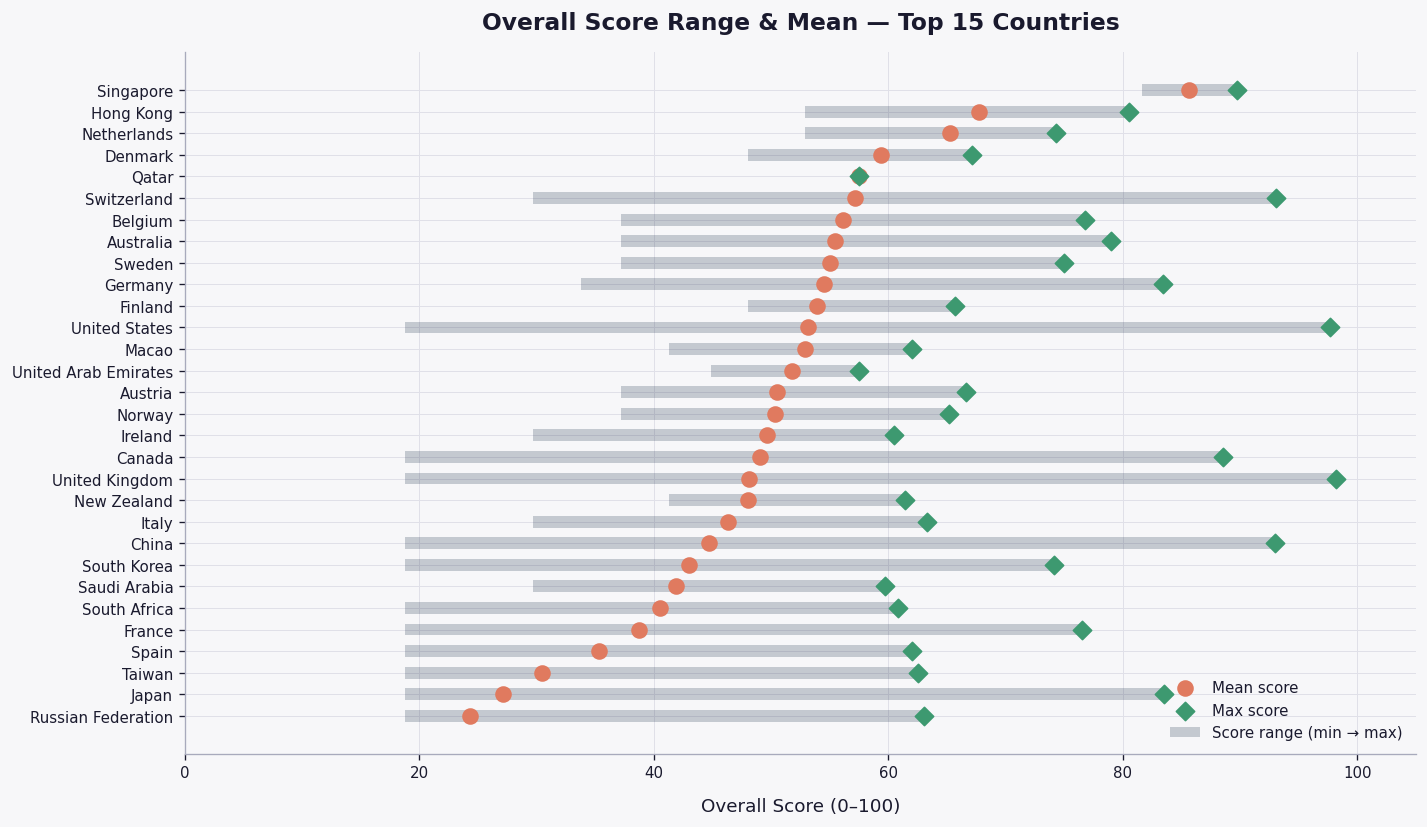

In [19]:
apply_theme()

country_stats = (
    df.groupby("country")["scores_overall"]
    .agg(["max", "mean", "min", "count"])
    .reset_index()
    .rename(columns={"max": "max_score", "mean": "avg_score",
                     "min": "min_score", "count": "university_count"})
    .sort_values(by=["max_score", "avg_score", "min_score"], ascending=False)
    .reset_index(drop=True)
)

top30 = country_stats.head(30).copy().sort_values("avg_score", ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))

ax.barh(
    top30["country"],
    top30["max_score"] - top30["min_score"],
    left=top30["min_score"],
    color=PALETTE["primary"], alpha=0.25, height=0.55, zorder=2,
    label="Score range (min → max)"
)
ax.scatter(top30["avg_score"], top30["country"],
           color=PALETTE["secondary"], s=80, zorder=4, label="Mean score")
ax.scatter(top30["max_score"], top30["country"],
           color=PALETTE["accent"], s=60, marker="D", zorder=4, label="Max score")

ax.set_xlabel("Overall Score (0–100)", labelpad=10)
ax.set_title("Overall Score Range & Mean — Top 15 Countries")
ax.legend(loc="lower right", fontsize=9)
ax.set_xlim(0, 105)

plt.tight_layout()
plt.show()

> **Key Insight:** Despite having globally top-ranked institutions, countries like the US and UK show significant spread between their best and worst scorers — pointing to **systemic inequality within national higher education**. Countries like **Singapore** — with fewer but highly focused institutions — show very narrow score ranges, indicating consistent quality throughout the system.

## 5. Score Breakdown by Metric — Top 10 Countries

The radar charts below display each country's **mean score profile** across five dimensions (Teaching, Research, Citations, Industry Income, International Outlook), making it easy to see relative strengths and weaknesses at a glance.

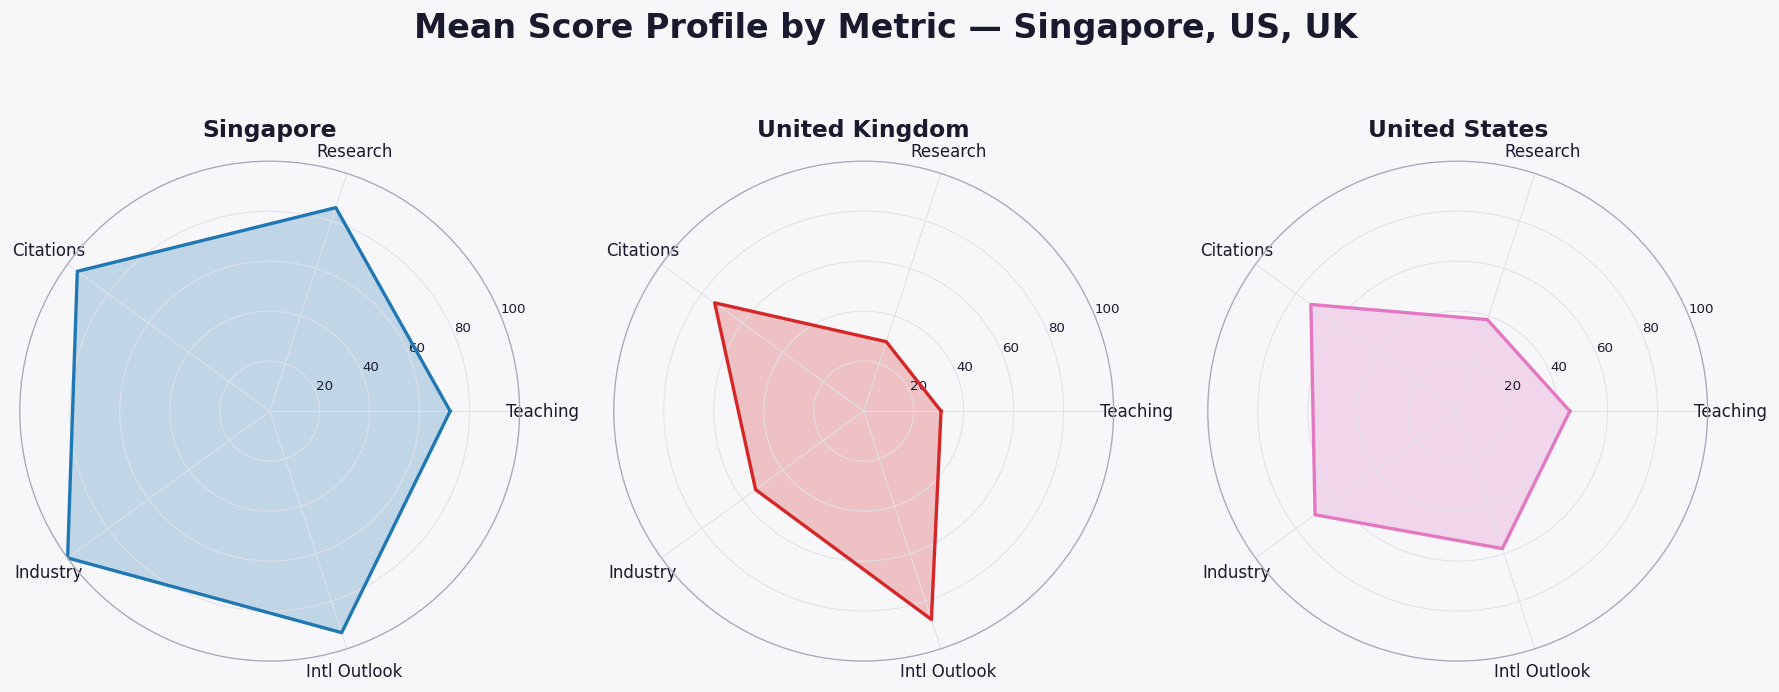

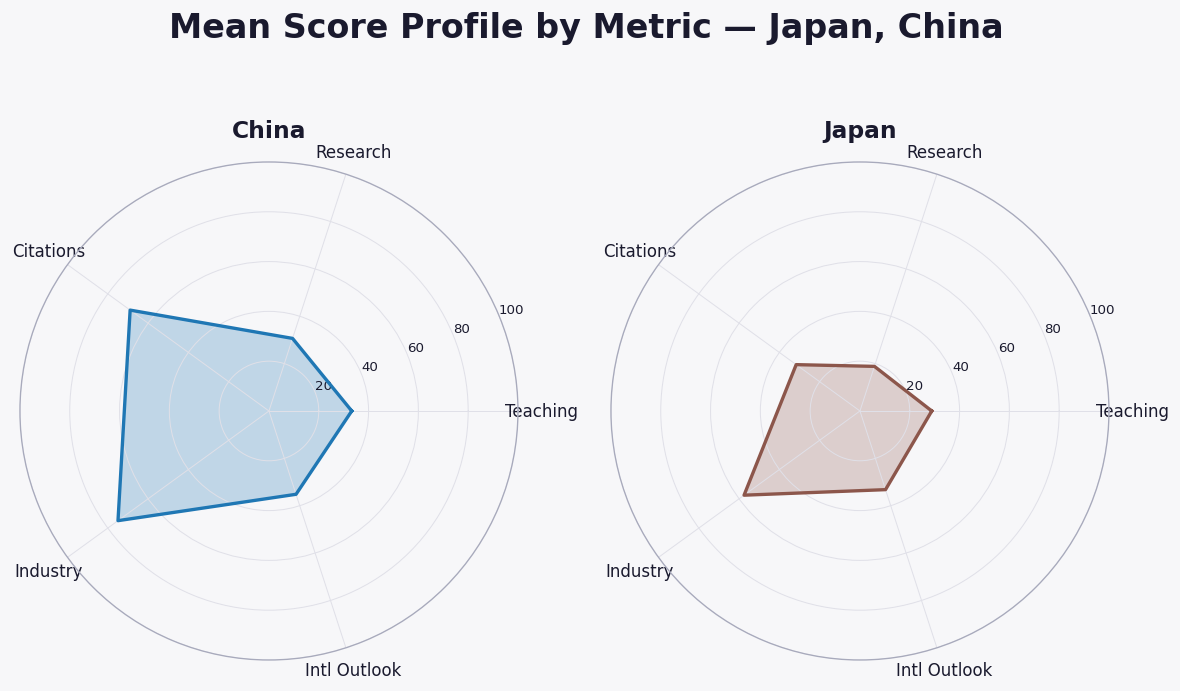

In [4]:
apply_theme()

score_cols = [
    "scores_teaching", "scores_research", "scores_citations",
    "scores_industry_income", "scores_international_outlook"
]
score_labels = ["Teaching", "Research", "Citations", "Industry", "Intl Outlook"]

df[score_cols] = df[score_cols].apply(pd.to_numeric, errors="coerce")

N_metrics      = len(score_labels)
angles_metrics = np.linspace(0, 2 * np.pi, N_metrics, endpoint=False).tolist() + [0]

# Singapore, United States, United Kingdom
countries_plot1 = ["Singapore", "United States", "United Kingdom"]
df_plot1 = df[df["country"].isin(countries_plot1)].copy()
country_mean_full_1 = df_plot1.groupby("country")[score_cols].mean().reset_index()

fig1, axes1 = plt.subplots(1, len(countries_plot1), figsize=(5 * len(countries_plot1), 6), subplot_kw=dict(polar=True))
if len(countries_plot1) == 1:
    axes1 = [axes1]
else:
    axes1 = axes1.flatten()

cmap1 = plt.get_cmap("tab10")

for idx, row in country_mean_full_1.iterrows():
    ax    = axes1[idx]
    vals  = row[score_cols].tolist() + [row[score_cols[0]]]
    color = cmap1(idx / len(country_mean_full_1))

    ax.plot(angles_metrics, vals, color=color, linewidth=2)
    ax.fill(angles_metrics, vals, color=color, alpha=0.25)
    ax.set_xticks(angles_metrics[:-1])
    ax.set_xticklabels(score_labels, size=10)
    ax.set_ylim(0, 100)
    ax.yaxis.set_tick_params(labelsize=8)
    ax.set_title(row["country"], size=14, fontweight="bold", pad=15)
    ax.set_facecolor(PALETTE["bg"])

fig1.suptitle("Mean Score Profile by Metric — Singapore, US, UK",
             fontsize=20, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# Japan, China
countries_plot2 = ["Japan", "China"]
df_plot2 = df[df["country"].isin(countries_plot2)].copy()
country_mean_full_2 = df_plot2.groupby("country")[score_cols].mean().reset_index()

fig2, axes2 = plt.subplots(1, len(countries_plot2), figsize=(5 * len(countries_plot2), 6), subplot_kw=dict(polar=True))
if len(countries_plot2) == 1:
    axes2 = [axes2]
else:
    axes2 = axes2.flatten()
cmap2 = plt.get_cmap("tab10")

for idx, row in country_mean_full_2.iterrows():
    ax    = axes2[idx]
    vals  = row[score_cols].tolist() + [row[score_cols[0]]]
    color = cmap2(idx / len(country_mean_full_2))

    ax.plot(angles_metrics, vals, color=color, linewidth=2)
    ax.fill(angles_metrics, vals, color=color, alpha=0.25)
    ax.set_xticks(angles_metrics[:-1])
    ax.set_xticklabels(score_labels, size=10)
    ax.set_ylim(0, 100)
    ax.yaxis.set_tick_params(labelsize=8)
    ax.set_title(row["country"], size=14, fontweight="bold", pad=15)
    ax.set_facecolor(PALETTE["bg"])

fig2.suptitle("Mean Score Profile by Metric — Japan, China",
             fontsize=20, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [11]:
# @title
import pandas as pd
import json
from IPython.display import HTML
from google.colab import output

# 1. Data Preparation
countries = ["Singapore", "United States", "United Kingdom", "Japan", "China"]
score_cols = [
    "scores_teaching", "scores_research", "scores_citations",
    "scores_industry_income", "scores_international_outlook"
]
score_labels = ["Teaching", "Research", "Citations", "Industry", "Intl Outlook"]

df_filtered = df[df["country"].isin(countries)].copy()
country_means = df_filtered.groupby("country")[score_cols].mean().round(2)

# Prepare Dataset for Chart.js
dashboard_data = {
    "labels": score_labels,
    "datasets": []
}

# Exact Tab10 palette for consistency
colors = [
    "rgba(31, 119, 180, 1)",  # China
    "rgba(255, 127, 14, 1)",  # Japan
    "rgba(44, 160, 44, 1)",   # Singapore
    "rgba(214, 39, 40, 1)",   # United Kingdom
    "rgba(148, 103, 189, 1)"  # United States
]

for i, (country, row) in enumerate(country_means.iterrows()):
    dashboard_data["datasets"].append({
        "label": country,
        "data": row.tolist(),
        "borderColor": colors[i],
        "backgroundColor": colors[i].replace(", 1)", ", 0.12)"),
        "borderWidth": 3,
        "pointRadius": 4,
        "fill": True
    })

# Top 50 table for the sidebar
table_data = df_filtered[["rank", "name", "country", "scores_overall"]].head(50).to_dict(orient="records")

html_content = """
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <script src="https://cdn.jsdelivr.net/npm/chart.js"></script>
    <style>
        :root { --primary: #2E4057; --accent: #E07A5F; --bg: #f4f6f8; --card: #ffffff; --text: #1a1a2e; --muted: #a8aabc; }
        body { font-family: 'Inter', sans-serif; background-color: var(--bg); margin: 0; padding: 20px; color: var(--text); }
        .header { display: flex; justify-content: space-between; align-items: flex-end; margin-bottom: 25px; }
        .header h1 { margin: 0; font-size: 24px; color: var(--primary); }

        .grid-container { display: grid; grid-template-columns: 1fr 380px; gap: 20px; }
        .card { background: var(--card); padding: 20px; border-radius: 12px; box-shadow: 0 4px 12px rgba(0,0,0,0.06); }

        .step-num { font-size: 10px; font-weight: 900; background: var(--primary); color: white; padding: 2px 6px; border-radius: 4px; margin-right: 8px; }
        .kpi-card h3 { margin: 0; font-size: 10px; color: var(--muted); text-transform: uppercase; letter-spacing: 1px; }
        .kpi-card p { margin: 8px 0 0; font-size: 22px; font-weight: bold; color: var(--primary); }

        .chart-box { height: 500px; display: flex; flex-direction: column; }
        .section-title { font-size: 12px; font-weight: bold; color: var(--accent); margin-bottom: 15px; text-transform: uppercase; }

        .table-box { height: 100%; overflow: hidden; display: flex; flex-direction: column; }
        .scroll-area { overflow-y: auto; flex-grow: 1; margin-top: 10px; }
        table { width: 100%; border-collapse: collapse; font-size: 12px; }
        th { text-align: left; padding: 8px; position: sticky; top: 0; background: white; border-bottom: 2px solid var(--bg); }
        td { padding: 8px; border-bottom: 1px solid var(--bg); }
        .badge { background: #eee; padding: 2px 5px; border-radius: 4px; font-weight: bold; }
    </style>
</head>
<body>


    <div class="grid-container">
        <div class="left-panel">

            <div class="card chart-box">
                <div style="position: relative; flex-grow: 1;"><canvas id="radarChart"></canvas></div>
            </div>
        </div>

        <div class="card table-box">
            <div class="section-title">06. Leading Institutions (Ranked)</div>
            <div class="scroll-area">
                <table id="topTable"><thead><tr><th>Rank</th><th>Name</th><th>Score</th></tr></thead><tbody></tbody></table>
            </div>
        </div>
    </div>

    <script>
        const dashboardData = DATA_PLACEHOLDER;
        const tableData = TABLE_PLACEHOLDER;

        // Populate Table
        const tbody = document.querySelector('#topTable tbody');
        tableData.forEach(row => {
            const tr = document.createElement('tr');
            tr.innerHTML = `<td><span class="badge">${row.rank}</span></td><td><b>${row.name}</b></td><td>${row.scores_overall}</td>`;
            tbody.appendChild(tr);
        });

        // Create Chart
        new Chart(document.getElementById('radarChart'), {
            type: 'radar',
            data: dashboardData,
            options: {
                responsive: true, maintainAspectRatio: false,
                scales: { r: { suggestedMin: 0, suggestedMax: 100, ticks: { backdropColor: 'transparent', stepSize: 20 } } },
                plugins: { legend: { position: 'bottom', labels: { padding: 20, usePointStyle: true, font: { weight: 'bold' } } } }
            }
        });
    </script>
</body>
</html>
""".replace('DATA_PLACEHOLDER', json.dumps(dashboard_data)) \
   .replace('TABLE_PLACEHOLDER', json.dumps(table_data[:12])) \


display(HTML(html_content))

Rank,Name,Score


> **Notable Observations:**
> - **Singapore** maintains only 2 ranked universities but both are exceptionally managed, resulting in tight, consistent scores across every metric.
> - This reveals a strategic trade-off: **breadth vs. depth**. Countries with fewer, well-resourced institutions tend to perform more consistently across all metrics.

## 6. Student Population & Staff Ratio Analysis

We examine total student enrolment distributions and compare student-to-staff ratios for the **UK and US**, the two most represented countries in the rankings.

A high student-to-staff ratio makes personalised education and quality management more challenging, which may feed back into lower teaching and overall scores.

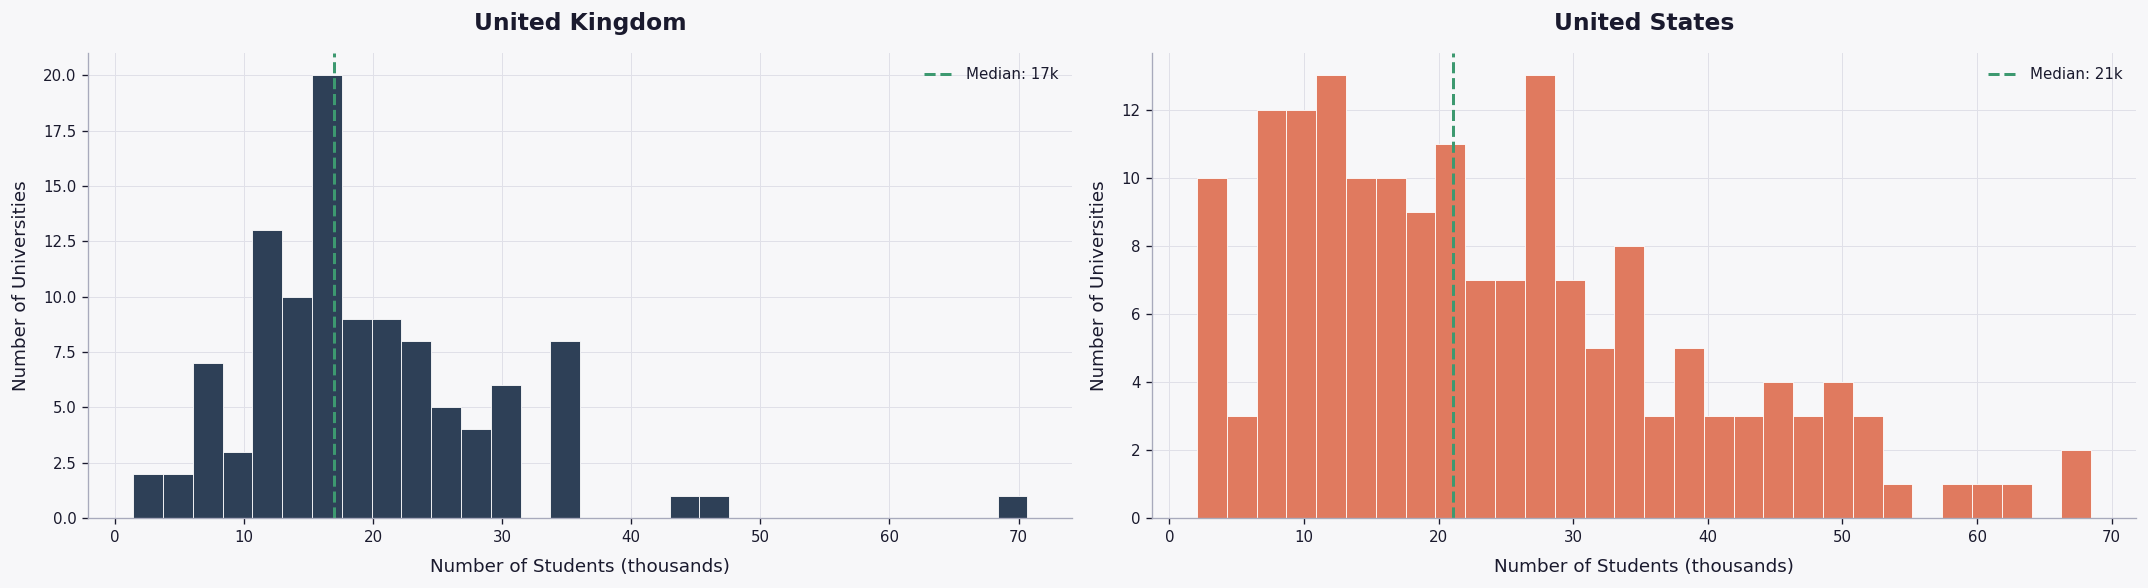

In [13]:
apply_theme()

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
country_list = ["United Kingdom", "United States"]
colors_list  = [PALETTE["primary"], PALETTE["secondary"]]


for ax, country, color in zip(axes[:2], country_list, colors_list):
    cdf       = df[df["country"] == country].copy()
    cdf_valid = cdf[cdf["stats_number_students"] > 0]["stats_number_students"]

    ax.hist(cdf_valid / 1_000, bins=30, color=color,
            edgecolor="white", linewidth=0.5, zorder=2)
    ax.set_title(country)
    ax.set_xlabel("Number of Students (thousands)", labelpad=8)
    ax.set_ylabel("Number of Universities", labelpad=8)

    median_k = cdf_valid.median() / 1_000
    ax.axvline(median_k, color=PALETTE["accent"], linewidth=1.8,
               linestyle="--", label=f"Median: {median_k:.0f}k")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

In [14]:
countries_to_analyze = ["Singapore", "United Kingdom", "United States"]

country_stats_filtered = df[df["country"].isin(countries_to_analyze)].groupby("country")[["stats_student_staff_ratio", "stats_number_students"]].mean().round(2)

print("Average Student-to-Staff Ratio and Student Population:")
print(country_stats_filtered)

Average Student-to-Staff Ratio and Student Population:
                stats_student_staff_ratio  stats_number_students
country                                                         
Singapore                           19.15               30708.50
United Kingdom                      17.26               19486.47
United States                       14.20               23740.13


## 7. Correlation Analysis

We investigate how all numeric features relate to each other and specifically:
- Does university **size** (student count) affect overall score?
- Does a higher **student-to-staff ratio** hurt scores?
- How tightly are **teaching and research** coupled?

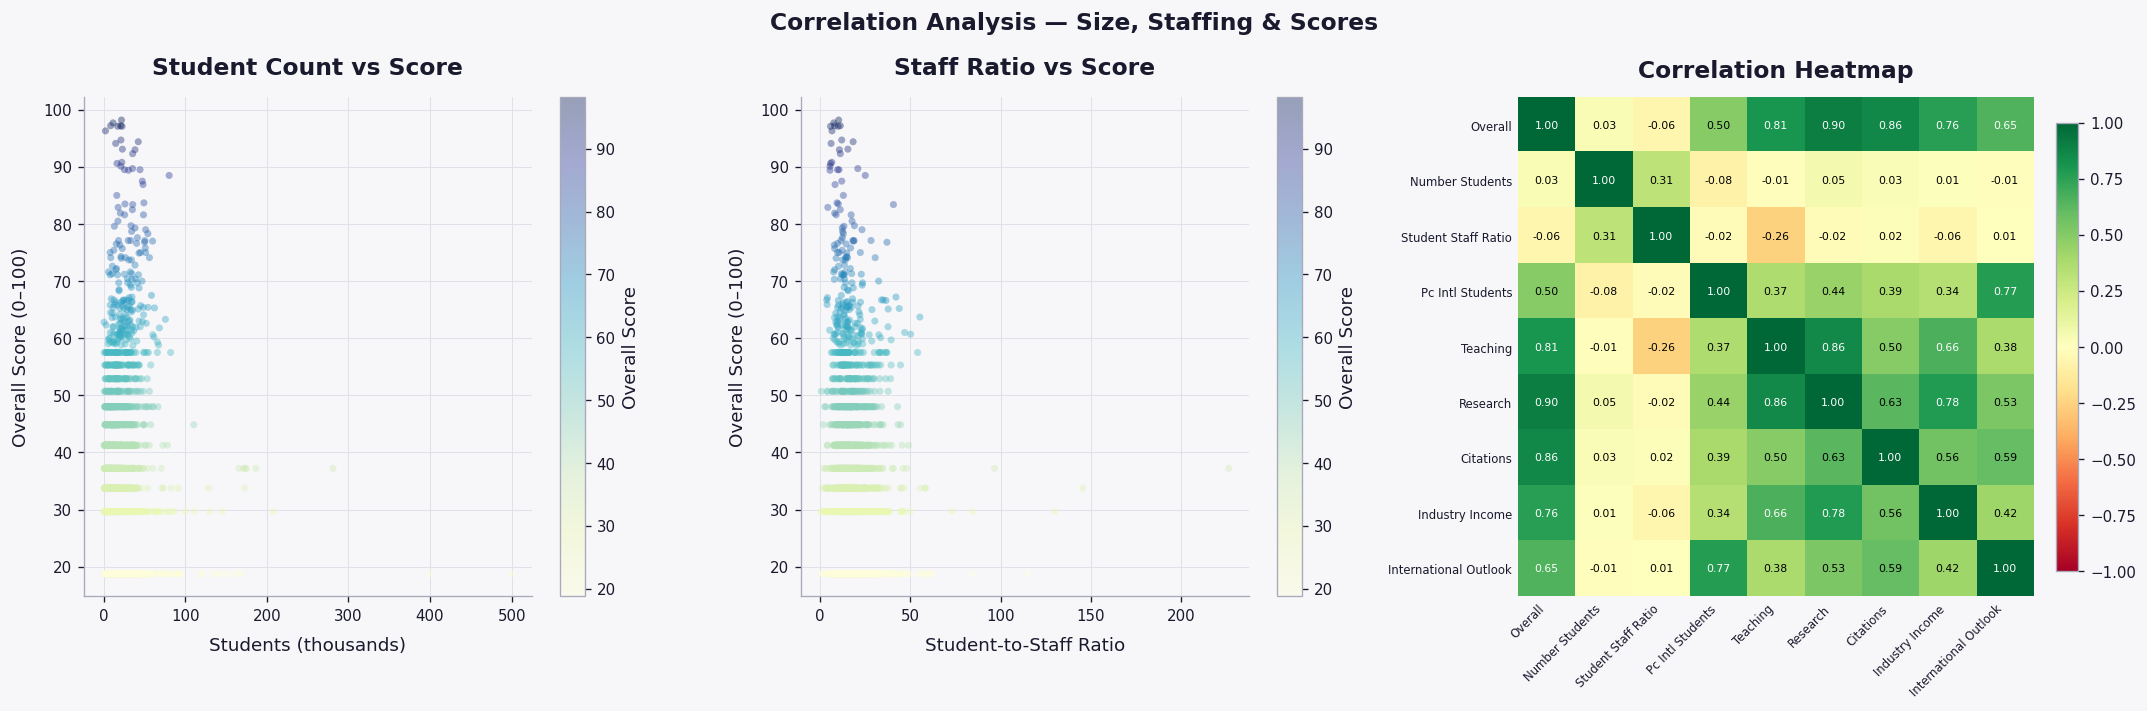

In [15]:
apply_theme()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# student count vs overall
ax = axes[0]
plot_df = df[(df["stats_number_students"] > 0) & (df["scores_overall"] > 0)].copy()
sc = ax.scatter(
    plot_df["stats_number_students"] / 1_000, plot_df["scores_overall"],
    alpha=0.4, s=18, c=plot_df["scores_overall"],
    cmap=SEQ_CMAP, edgecolors="none", zorder=2
)
plt.colorbar(sc, ax=ax, label="Overall Score")
ax.set_xlabel("Students (thousands)", labelpad=8)
ax.set_ylabel("Overall Score (0–100)", labelpad=8)
ax.set_title(f"Student Count vs Score")

# student staff ratio vs overall
ax = axes[1]
plot_df2 = df[(df["stats_student_staff_ratio"] > 0) & (df["scores_overall"] > 0)].copy()
plot_df2["stats_student_staff_ratio"] = pd.to_numeric(
    plot_df2["stats_student_staff_ratio"], errors="coerce"
)
plot_df2 = plot_df2.dropna(subset=["stats_student_staff_ratio"])
sc2 = ax.scatter(
    plot_df2["stats_student_staff_ratio"], plot_df2["scores_overall"],
    alpha=0.4, s=18, c=plot_df2["scores_overall"],
    cmap=SEQ_CMAP, edgecolors="none", zorder=2
)
plt.colorbar(sc2, ax=ax, label="Overall Score")
ax.set_xlabel("Student-to-Staff Ratio", labelpad=8)
ax.set_ylabel("Overall Score (0–100)", labelpad=8)
ax.set_title(f"Staff Ratio vs Score")

# heatmap
ax = axes[2]
numeric_df = df.select_dtypes(include=["number"]).copy()
drop_rank  = [c for c in numeric_df.columns if "rank" in c.lower()]
numeric_df = numeric_df.drop(columns=drop_rank, errors="ignore")
corr = numeric_df.corr()

im = ax.imshow(corr, cmap=DIV_CMAP, vmin=-1, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax, fraction=0.04, pad=0.04)

n = len(corr.columns)
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.grid(False)
ax.tick_params(axis="both", which="both", length=0)
for spine in ax.spines.values():
    spine.set_visible(False)

labels = [c.replace("scores_","").replace("stats_","").replace("_"," ").title()
          for c in corr.columns]
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=7)
ax.set_yticklabels(labels, fontsize=7)

for i in range(n):
    for j in range(n):
        val = corr.iloc[i, j]
        tc  = "white" if abs(val) > 0.65 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                color=tc, fontsize=6.5)

ax.set_title("Correlation Heatmap", pad=12)

fig.suptitle("Correlation Analysis — Size, Staffing & Scores",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Key Correlations Unpacked:**

| Pair | r | Interpretation |
|------|---|----------------|
| Teaching ↔ Research | ~0.86 | Tightly coupled academic quality — institutions strong in pedagogy are almost universally strong in research |
| Research ↔ Industry Income | ~0.77 | Strong but incomplete — research strength frequently translates into industry collaboration, but conversion depends on applied focus |
| Intl Students ↔ Intl Outlook | ~moderate | Universities with more international students tend to score higher on international outlook |
| Student-Staff Ratio ↔ Teaching | ~−0.26 | A higher ratio modestly depresses teaching scores — attention and resources get diluted |

> Teaching quality is driven far more by institutional prestige and research strength than by staffing density alone — but reducing the student-to-staff ratio remains a practical, controllable lever.

## 8. International Outlook vs. Performance

 Does a university's openness to the world — measured by the share of international students — predict its overall performance? We explore this relationship and compare how the **top 10 countries** position themselves on the international-student dimension.

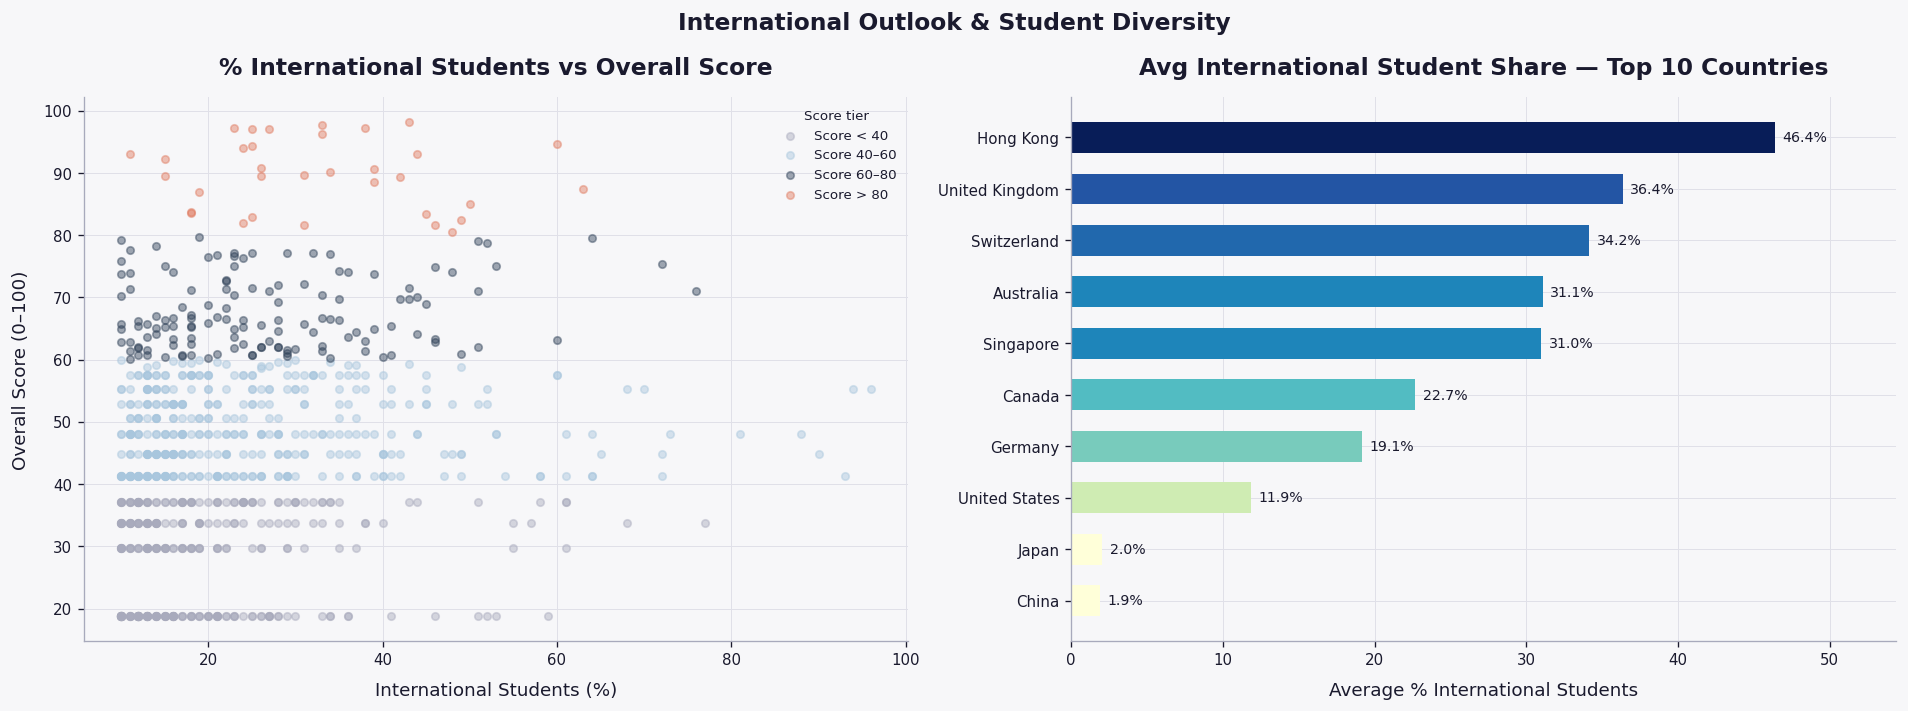

In [16]:
apply_theme()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# international students vs overall
ax = axes[0]
plot_df3 = df[(df["stats_pc_intl_students" ] > 0) & (df["scores_overall"] > 0)].copy()

# Colour-code by broad score tier
bins   = [0, 40, 60, 80, 101]
labels_tier = ["< 40", "40–60", "60–80", "> 80"]
tier_colors = [PALETTE["muted"], "#A8C6DD", PALETTE["primary"], PALETTE["secondary"]]
plot_df3["tier"] = pd.cut(plot_df3["scores_overall"], bins=bins, labels=labels_tier)

for tier, color in zip(labels_tier, tier_colors):
    sub = plot_df3[plot_df3["tier"] == tier]
    ax.scatter(sub["stats_pc_intl_students"], sub["scores_overall"],
               alpha=0.45, s=20, color=color, label=f"Score {tier}", zorder=2)

ax.set_xlabel("International Students (%)", labelpad=8)
ax.set_ylabel("Overall Score (0–100)", labelpad=8)
ax.set_title(f"% International Students vs Overall Score")
ax.legend(fontsize=8, title="Score tier", title_fontsize=8)

# avg intl students
ax2 = axes[1]

countries_10 = [
    "United Kingdom", "United States", "Switzerland",
    "China", "Singapore", "Canada",
    "Japan", "Germany", "Hong Kong", "Australia"
]
intl_by_country = (
    df[df["country"].isin(countries_10)]
    .groupby("country")["stats_pc_intl_students"]
    .mean()
    .reset_index()
    .sort_values("stats_pc_intl_students", ascending=True)
)

import matplotlib.cm as cm
norm2   = plt.Normalize(intl_by_country["stats_pc_intl_students"].min(),
                        intl_by_country["stats_pc_intl_students"].max())
colors2 = [cm.YlGnBu(norm2(v)) for v in intl_by_country["stats_pc_intl_students"]]

bars2 = ax2.barh(intl_by_country["country"],
                 intl_by_country["stats_pc_intl_students"],
                 color=colors2, height=0.6, zorder=2)

for bar, val in zip(bars2, intl_by_country["stats_pc_intl_students"]):
    ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
             f"{val:.1f}%", va="center", fontsize=8.5)

ax2.set_xlabel("Average % International Students", labelpad=8)
ax2.set_title("Avg International Student Share — Top 10 Countries")
ax2.set_xlim(0, intl_by_country["stats_pc_intl_students"].max() + 8)

fig.suptitle("International Outlook & Student Diversity",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

> **Key Insight** There is a meaningful positive correlation between international student share and overall score — universities with a more globally diverse student body tend to perform better. **Hong Kong, Switzerland, and Singapore** stand out as the most internationally open systems among top-ranked countries, while **Japan and China** remain largely domestic in student composition. This suggests that actively recruiting international talent is not just a diversity metric — it is a **performance signal**.  

## 9. Key Findings & Recommendations

### Some Interesting Notable Points

| Theme | Finding |
|-------|---------|
| **Top Countries by Volume** | US, India, and Japan have the most universities in the global rankings |
| **Elite Dominance** | The top 10 is almost exclusively UK and US institutions (Oxford, MIT, Princeton, …) |
| **Score Inequality** | Countries with many universities show high variance between their best and worst scorers |
| **Singapore Model** | Fewer but highly focused institutions result in consistently strong performance across all metrics |
| **Student Size Effect** | Very large student populations correlate weakly but negatively with overall scores |
| **Staff Ratio Effect** | Higher student-to-staff ratios consistently correlate with lower scores — attention and resources get diluted |
| **Teaching–Research Coupling** | Strong correlation (r ≈ 0.86) — institutions that excel at one almost always excel at the other |
| **International Openness** | Higher % of international students correlates with better performance (e.g. China, Japan, etc.) |

---

### Suggestions and Expectations

1. **Focus over volume.**  
   Countries with many lower-ranked institutions should consider consolidating resources into fewer, better-supported universities rather than expanding headcount.

2. **Hire more academic staff.**  
   Reducing the student-to-staff ratio is one of the most *actionable and measurable* levers available to improve both teaching scores and overall rankings.

3. **Set sensible enrollment caps.**  
   Defining upper limits on student intake at the institutional level can prevent quality dilution as student numbers grow.

4. **Bridge the research-to-industry gap.**  
   Universities with strong research scores that underperform on industry income should invest in technology transfer offices, industry partnerships, and applied research tracks.

5. **Invest in internationalisation.**  
   Actively recruiting international students and faculty is not merely a diversity initiative — it has measurable impact on overall performance scores.

6. **Learn from Singapore.**  
   Maintaining a smaller, elite set of universities with strong international outlook and concentrated research investment is a replicable model for any country willing to prioritise depth over breadth.

---

*Times Higher Education (THE) World University Rankings Analysis*